# ADCP Raw Data Processing

In [ ]:
from mhkit import dolfyn
from mhkit.dolfyn.adp import api
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
ds = dolfyn.read("A0524000.000")
ds

#why is time in ns? does it matter, should it be changed?


Reading file A0524000.000 ...


<xarray.Dataset> Size: 13MB
Dimensions:              (time: 16864, range: 24, beam: 4, dir: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 135kB 2024-05-13T12:00:00 ... ...
  * range                (range) float32 96B 2.12 3.12 4.12 ... 24.12 25.12
  * beam                 (beam) int32 16B 1 2 3 4
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 67kB 1 2 3 4 ... 16861 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.534e+03 1.534e+03 ... 1.518e+03
    depth                (time) float32 67kB 0.0 0.0 0.0 0.0 ... 22.3 22.4 22.5
    pitch                (time) float32 67kB -4.2 -4.22 -4.2 ... -6.7 -6.7 -6.68
    roll                 (time) float32 67kB -0.07 -0.04 -0.04 ... -1.28 -1.28
    ...                   ...
    vel                  (dir, range, time) float32 6MB 0.017 nan ... nan nan
    amp                  (beam, range, time) uint8 2MB 55 55 55 ... 119 122 118
    corr                 (beam, range, time) uint8 2MB 70 73 70 ... 108 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 5 0 0 2 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 607kB -0.7555 ... -0.993
Attributes: (12/38)
    firmware_ver:             50.4
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              ['vel']
    has_imu:                  0
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.25
    bandwidth:                0
    power_level:              255
    serialnum:                21788
    range_offset:             0.24
    fs:                       0.0011363636363636363

### 1. Controlling that bin heights are correct

In [5]:
#not sure if 0 corresponds to seafloor
#is center of fist bin corresponding to deployment height(?) + blank distance + cell size/2 ?
print(f"Blank distance: {ds.attrs.get('blank_dist')}")
print(f"Cell size: {ds.attrs.get('cell_size')}")
print(f"Range values: {ds['range'].values}")

Blank distance: 0.88
Cell size: 1.0
Range values: [ 2.12  3.12  4.12  5.12  6.12  7.12  8.12  9.12 10.12 11.12 12.12 13.12
 14.12 15.12 16.12 17.12 18.12 19.12 20.12 21.12 22.12 23.12 24.12 25.12]


### 2. Removing surface interference

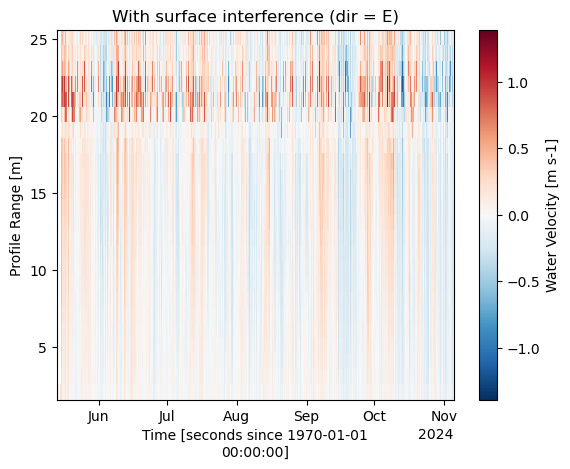

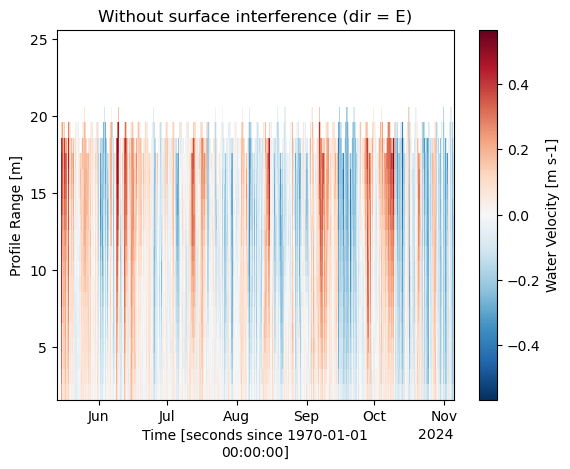

In [6]:
ds["vel"][0].plot() 
plt.title("With surface interference (dir = E)")
plt.show()

ds_2 = api.clean.remove_surface_interference(ds) 
ds_2["vel"][0].plot()
plt.title("Without surface interference (dir = E)")
plt.show()


### 3. Applying correlation filter

In [7]:
thresh=100
ds_3 = api.clean.correlation_filter(ds_2, thresh=thresh) 


#a lot of the data was already NaN, checking how much of non NaN data is removed
before = np.isfinite(ds_2.vel.values).sum()  
after = np.isfinite(ds_3.vel.values).sum()
removed = before - after
percent_removed = (removed / before) * 100

print(f"Non NaN data removed: {removed} ({percent_removed:.2f}%) at threshold = {thresh}")


Non NaN data removed: 30672 (2.63%) at threshold = 100


### 4. Controlling coordinate system and setting declination

In [8]:
#earth coordinate system is already used
print(f"Coordinate system: {ds.attrs['coord_sys']}")

#need to set declination
print(f"Declination: {ds.attrs.get('declination', 'Not set')}")

dolfyn.set_declination(ds_3, -0.90) #I assumed lat=37N, long=8W, May 2024 which gave declination=0.9W
print(f"Declination: {ds_3.attrs.get('declination', 'Not set')}")

Coordinate system: earth
Declination: Not set
Declination: -0.9


### 5. Checking if data is averaged

In [9]:
#seems like it is
print(f"Time step: {ds.time.diff('time').median().values}")


Time step: 900000000000 nanoseconds


### 6. Filtering out interal waves (?) and tides

I want to
- convert from time domain to frequency domain
- filter out certain frequencies, semi-diurnal tidal range is about 2-2.5 Hz
do I then need to make my own filter, e.g. with scipy, or is there any easier way?


### Other thoughts:
Should I calculate cross-shore and long-shore velocities, should be interesting for upwelling and wind induced currents?

### 7. Saving data

In [10]:
dolfyn.save(ds_3, 'ADCP_processed_0524.nc')